1. Import Libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

2. Connect to Website

In [2]:
url = "https://realpython.github.io/fake-jobs/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

Status Code: 200


3. Parse HTML

In [3]:
soup = BeautifulSoup(response.text, "html.parser")

4. Find All Jobs

In [4]:
jobs = soup.find_all("div", class_="card-content")

print("Total Jobs:", len(jobs))

Total Jobs: 100


5. Create Empty Lists

In [5]:
job_titles = []
companies = []
locations = []
dates = []
links = []

6. Extract Job Details

In [6]:
for job in jobs:

    title = job.find("h2", class_="title")
    title = title.text.strip() if title else "Not Available"

    company = job.find("h3", class_="company")
    company = company.text.strip() if company else "Not Available"

    location = job.find("p", class_="location")
    location = location.text.strip() if location else "Not Available"

    date = job.find("time")
    date = date["datetime"] if date else "Not Available"

    apply_link = job.find_next("a")

    if apply_link:
        apply_link = apply_link["href"]
    else:
        apply_link = "Not Available"

    job_titles.append(title)
    companies.append(company)
    locations.append(location)
    dates.append(date)
    links.append(apply_link)

7. Create DataFrame

In [7]:
df = pd.DataFrame({
    "Job Title": job_titles,
    "Company": companies,
    "Location": locations,
    "Date Posted": dates,
    "Apply Link": links
})

df.head()

,Job Title,Company,Location,Date Posted,Apply Link
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",2021-04-08,https://www.realpython.com
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",2021-04-08,https://www.realpython.com
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",2021-04-08,https://www.realpython.com
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",2021-04-08,https://www.realpython.com
4,Product manager,Ramirez Inc,"North Jamieview, AP",2021-04-08,https://www.realpython.com


8. Check Dataset

In [8]:
df.shape

(100, 5)

9. Save CSV

In [9]:
df.to_csv("Fake_Jobs.csv", index=False)

print("CSV Saved Successfully")

CSV Saved Successfully


10. Basic Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Job Title    100 non-null    object
 1   Company      100 non-null    object
 2   Location     100 non-null    object
 3   Date Posted  100 non-null    object
 4   Apply Link   100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


11. Check Missing Values

In [11]:
df.isnull().sum()

Job Title      0
Company        0
Location       0
Date Posted    0
Apply Link     0
dtype: int64

12. Remove Duplicate Records

In [12]:
df = df.drop_duplicates()

print("Duplicates Removed")

Duplicates Removed


13. Check Final Shape

In [13]:
df.shape

(100, 5)

14. Save Clean Dataset

In [14]:
df.to_csv("Fake_Jobs_Cleaned.csv", index=False)

print("Cleaned Dataset Saved")

Cleaned Dataset Saved


15. Number of Rows and Columns

In [15]:
print("Rows and Columns:", df.shape)

Rows and Columns: (100, 5)


16. Column Names

In [16]:
print(df.columns)

Index(['Job Title', 'Company', 'Location', 'Date Posted', 'Apply Link'], dtype='object')


17. Data Types

In [17]:
print(df.dtypes)

Job Title      object
Company        object
Location       object
Date Posted    object
Apply Link     object
dtype: object


18. Summary Statistics

In [18]:
df.describe(include="all")

,Job Title,Company,Location,Date Posted,Apply Link
count,100,100,100,100,100
unique,92,99,100,1,1
top,Python Programmer (Entry-Level),Garcia PLC,"Stewartbury, AA",2021-04-08,https://www.realpython.com
freq,3,2,1,100,100


19. Top 10 Companies

In [19]:
top_companies = df["Company"].value_counts().head(10)

print(top_companies)

Company
Garcia PLC                        2
Payne, Roberts and Davis          1
Smith PLC                         1
Wood Inc                          1
Patton, Haynes and Jones          1
Blankenship, Knight and Powell    1
Jackson, Ali and Mckee            1
Leblanc LLC                       1
Vasquez Ltd                       1
Bailey, Owen and Thompson         1
Name: count, dtype: int64


20. Bar Chart - Top Companies

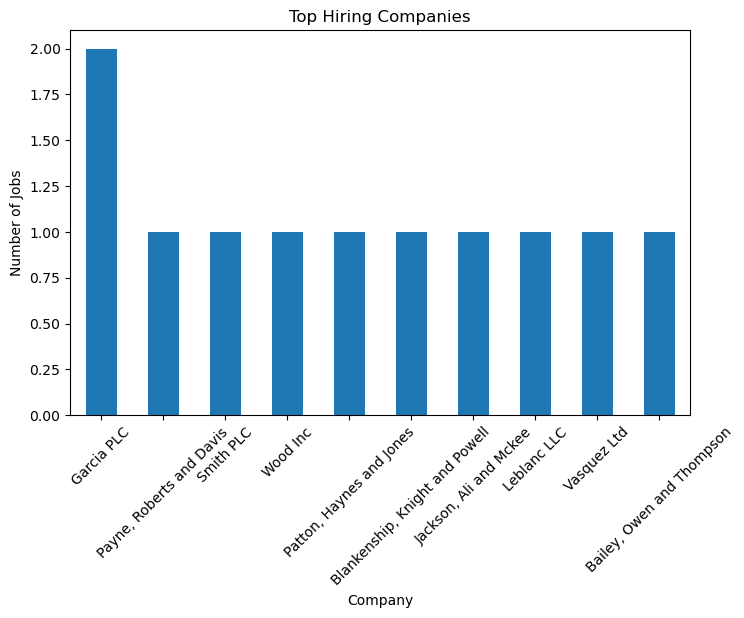

In [20]:
top_companies.plot(kind="bar", figsize=(8,5))

plt.title("Top Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

21. Top 10 Locations

In [21]:
top_locations = df["Location"].value_counts().head(10)

print(top_locations)

Location
Stewartbury, AA          1
Port Devonville, AE      1
Port Jeremy, AA          1
Lloydton, AP             1
Millsbury, AE            1
New Elizabethside, AA    1
Lake Antonio, AA         1
New Kelly, AP            1
Jamesville, AA           1
Davidside, AA            1
Name: count, dtype: int64


22. Bar Chart - Top Locations

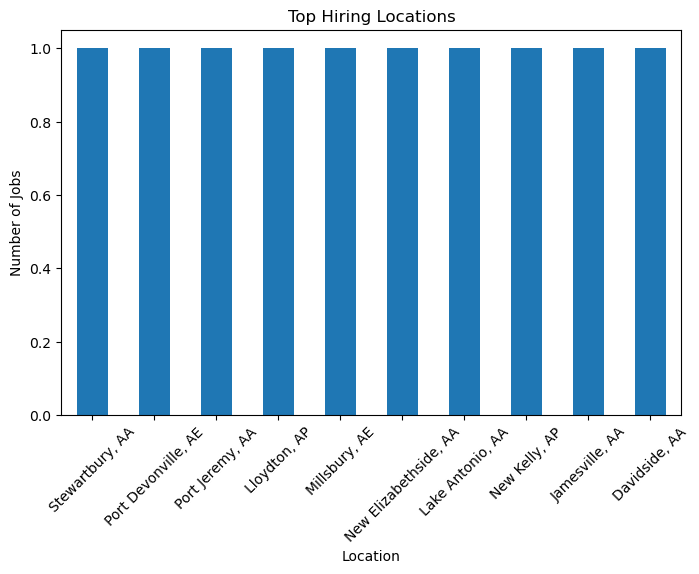

In [22]:
top_locations.plot(kind="bar", figsize=(8,5))

plt.title("Top Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

23. Most Common Job Titles

In [23]:
top_jobs = df["Job Title"].value_counts().head(10)

print(top_jobs)

Job Title
Python Programmer (Entry-Level)            3
Legal executive                            2
Manufacturing systems engineer             2
Materials engineer                         2
Futures trader                             2
Software Developer (Python)                2
Back-End Web Developer (Python, Django)    2
Senior Python Developer                    1
Insurance underwriter                      1
Forest/woodland manager                    1
Name: count, dtype: int64


24. Bar Chart - Job Titles

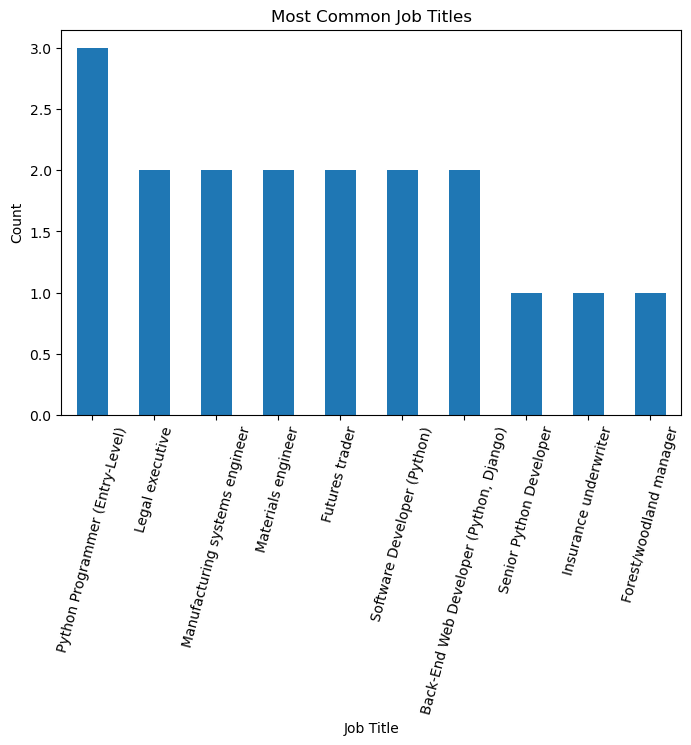

In [24]:
top_jobs.plot(kind="bar", figsize=(8,5))

plt.title("Most Common Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=75)

plt.show()

25. Pie Chart - Top 5 Companies

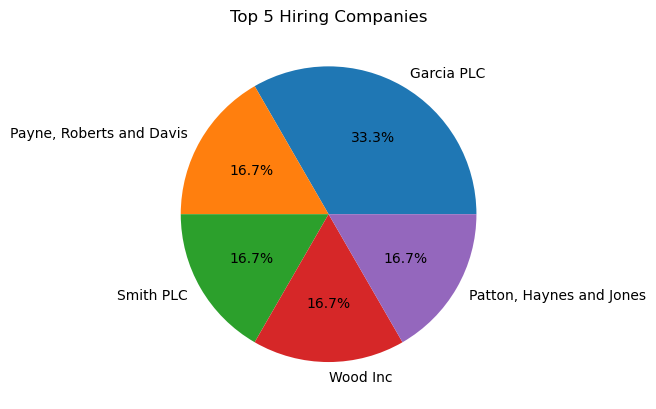

In [25]:
top5 = df["Company"].value_counts().head(5)

top5.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Top 5 Hiring Companies")

plt.show()

26. Jobs by Location

In [26]:
location_count = df.groupby("Location").size()

print(location_count)

Location
Adamburgh, AA        1
Alberttown, AE       1
Amyborough, AA       1
Angelastad, AP       1
Arnoldhaven, AE      1
                    ..
Williambury, AA      1
Williamsburgh, AE    1
Wilsonmouth, AA      1
Wrightberg, AP       1
Zacharyport, AA      1
Length: 100, dtype: int64


27. Unique Companies

In [27]:
print("Unique Companies:", df["Company"].nunique())

Unique Companies: 99


28. Unique Locations

In [28]:
print("Unique Locations:", df["Location"].nunique())

Unique Locations: 100


29. Unique Job Titles

In [29]:
print("Unique Job Titles:", df["Job Title"].nunique())

Unique Job Titles: 92


30. Final Dataset Preview

In [30]:
df.tail()

,Job Title,Company,Location,Date Posted,Apply Link
95,Museum/gallery exhibitions officer,"Nguyen, Yoder and Petty","Lake Abigail, AE",2021-04-08,https://www.realpython.com
96,"Radiographer, diagnostic",Holder LLC,"Jacobshire, AP",2021-04-08,https://www.realpython.com
97,Database administrator,Yates-Ferguson,"Port Susan, AE",2021-04-08,https://www.realpython.com
98,Furniture designer,Ortega-Lawrence,"North Tiffany, AA",2021-04-08,https://www.realpython.com
99,Ship broker,"Fuentes, Walls and Castro","Michelleville, AP",2021-04-08,https://www.realpython.com


31. Save Final Dataset

In [31]:
df.to_csv("Final_Fake_Jobs_Dataset.csv", index=False)

print("Final Dataset Saved Successfully")

Final Dataset Saved Successfully
